**Обучение на частично размеченном датасете.  
Метод Self-Training.**


Евгений Борисов <esborisov@sevsu.ru>

---

$X,Y$ - учебный набор, частично размеченный;   
$X^ℓ = \lbrace x_1,\ldots, x_ℓ \rbrace$, $\lbrace y_1, \ldots, y_ℓ \rbrace$ - размеченная часть выборки (labeled data);    
$X^k = \lbrace x_{ℓ+1},\ldots, x_{ℓ+k} \rbrace$ - неразмеченная часть выборки (unlabeled data);	

$b_y(x)$ - оценка принадлежности объекта $x$ к классу $y$

классификатор - выбираем для объекта $x$ класс $y$ с наилучшей оценкой $b$ ;

$$a(x) = \arg \max_{у\in Y} b_y(x)$$

In [1]:
import numpy as np
from numpy import random as rng

# генерируем данные 

(1024, 2)

(1024,)

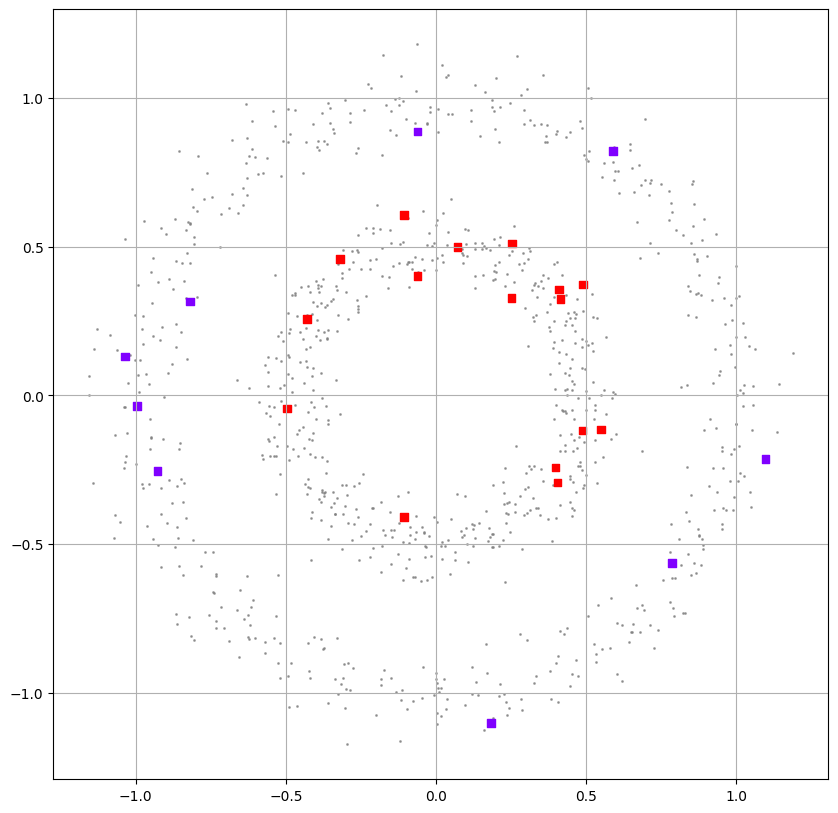

In [2]:
n_samples=1024

# генерируем датасет

# from sklearn.datasets import make_moons
# X, target = make_moons(n_samples=n_samples,noise=.1)

from sklearn.datasets import make_circles
X, target = make_circles(n_samples=n_samples,noise=.07,factor=0.5)
display( X.shape, target.shape )


# случайным образом делим датасет на размеченный и неразмеченный
from sklearn.model_selection import train_test_split

train_size=n_samples//40
( _, _, target_train, _, indices_train, indices_test ) = train_test_split( X, target, np.arange(n_samples), train_size=train_size )

# разметка должна содержать позитивные и негативные метки
assert 0 < target_train.sum() < train_size

from matplotlib import pyplot as plt

fig,ax = plt.subplots(1,figsize=(10,10))
ax.scatter(X[indices_test,0], X[indices_test,1],  c='grey',s=1,alpha=0.7)
ax.scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax.grid()
plt.show()

# "простой" классификатор

In [3]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier( n_neighbors=3, metric='euclidean', ).fit( X[indices_train,:], target_train )

In [4]:
# from matplotlib.colors import ListedColormap

from sklearn.preprocessing import MinMaxScaler
# строим сетку 
n = 64 # количество разбиений сетки
xx,yy = np.meshgrid(
    np.linspace( X[:,0].min()-0.1, X[:,0].max()+0.1, n), 
    np.linspace( X[:,1].min()-0.1, X[:,1].max()+0.1, n)
) # узлы сетки
xy = np.vstack([xx.ravel(),yy.ravel()]).T # разворачиваем сетку 


              precision    recall  f1-score   support

           0       0.99      0.51      0.67       512
           1       0.67      0.99      0.80       512

    accuracy                           0.75      1024
   macro avg       0.83      0.75      0.74      1024
weighted avg       0.83      0.75      0.74      1024



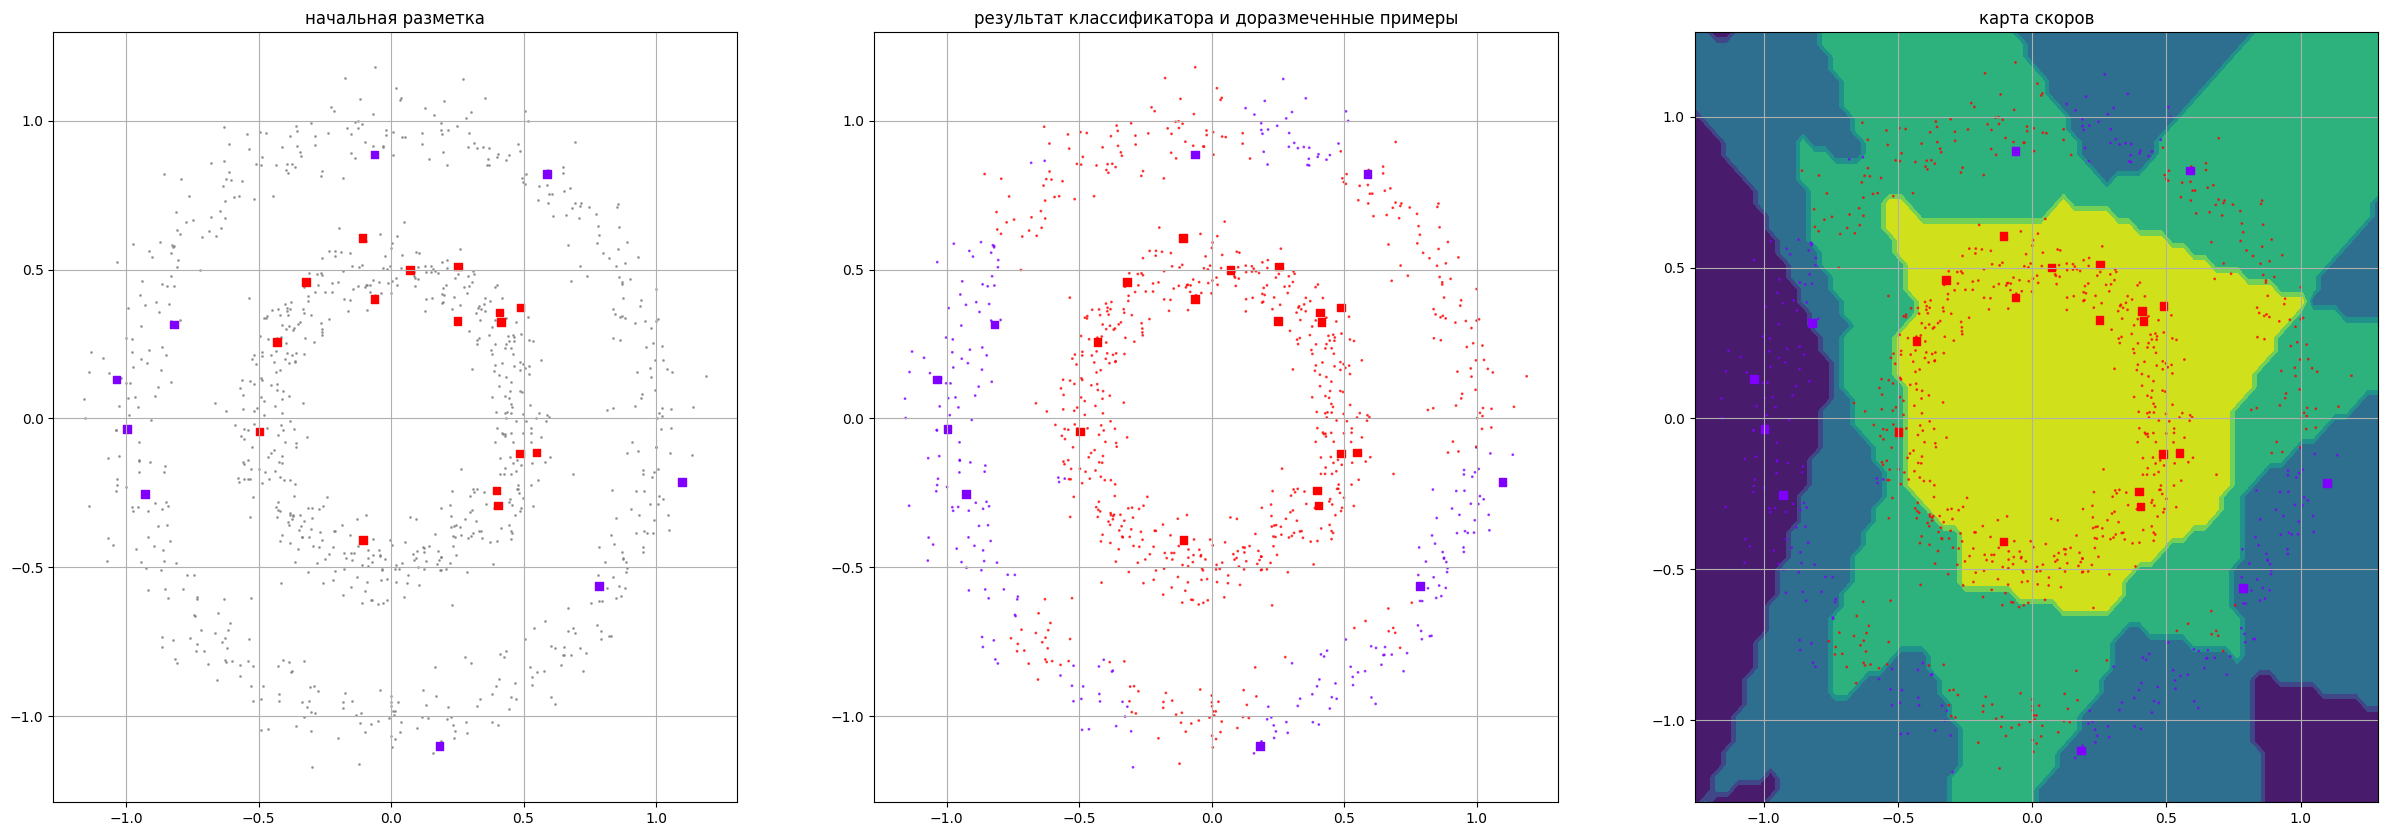

In [5]:
p = model.predict(X)

from sklearn.metrics import classification_report
print(classification_report(y_true=target,y_pred=p))

fig,ax = plt.subplots(1,3,figsize=(30,10))

ax[0].scatter(X[:,0],X[:,1],c='grey',s=1,alpha=0.7)
ax[0].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[0].set_title('начальная разметка')
ax[0].grid()

ax[1].scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=1,alpha=0.7)
ax[1].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[1].set_title('результат классификатора и доразмеченные примеры')
ax[1].grid()

# вычисляем скор позитивных примеров для каждого узла сетки
score_xy = MinMaxScaler(feature_range=(0.,1.)).fit_transform( model.predict_proba(xy)[:,[1]] ).reshape(n,n) 
ax[2].contourf(xx, yy, score_xy )
ax[2].scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=1,alpha=0.7)
ax[2].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[2].set_title('карта скоров')
ax[2].grid()

plt.show()

In [6]:
# s = model.predict_proba(X[indices_test])
# s_max, s_std = s.max(), s.std()
# display((s_max, s_std))
# display(( len(indices_test), len(n) ))

# n,c = np.where( s > (s_max-s_std*1e-9) )
# display( n,c )

# Self-Training классификатор

David Yarowsky    
Unsupervised word sense disambiguation rivaling supervised methods.    
Proceedings of the 33rd annual meeting on Association for Computational Linguistics (ACL ‘95).     
Association for Computational Linguistics, Stroudsburg, PA, USA, 189-196.   
https://dl.acm.org/doi/pdf/10.3115/981658.981684

---

оценка "степень доверия" классификации,  
насколько оценка класса-победителя лучше оценок остальных классов


$$ y = a(b(x)) $$
$$ M(x|a) = \max_{y\in Y} b_y(x) - \max_{q\in Y\setminus y}  b_q(x) $$

Алгоритм self-training — обёртка (wrapper) над произвольным методом обучения классификатора:
    

    
Z := Xℓ ;

пока |Z| < ℓ+k:  
- $a(b((Z))$ ; обучить классификатор $a$ на размеченных данных $Z$
- $X_∆ := \lbrace x\ |\ x \in X^k\setminus Z\ ; M(x|a) > M_0 \rbrace$ ; оценить неразмеченные и выбрать "надёжные"
- $y_∆ := \lbrace  a(x) | x \in X_∆ \rbrace $  ; доразметить "надёжные"
- $Z := Z \cup \lbrace X_∆, y_∆ \rbrace$ ; добавить новые к размеченным  


In [8]:
from tqdm.cli import tqdm

class SelfTrainingClassifier:

    def __init__(self, model_class, model_args):
        self._model_class = model_class
        self._model_args = model_args
        
    def fit(self,X,target):
        target_ = target.copy()
        for i in tqdm( range(len(target_)) ):
            # разделяем размеченные и неразмеченные
            indices_labeled = np.where(target_>-1)[0]
            indices_unlabeled = np.where(target_==-1)[0]

            # обучаем модель на размеченных
            model = self._model_class(**self._model_args).fit(X[indices_labeled],target_[indices_labeled])

            if len(indices_unlabeled)<1: break # все размечены, конец работы

            # считаем скор неразмеченных
            s = model.predict_proba(X[indices_unlabeled])
            
            # выбираем один пример с максимальным скором
            n, c = np.unravel_index( np.argmax(s), s.shape )

            # # выбираем все примеры со скором близким к максимальному
            # s_max, s_std =  s.max(), s.std()
            # n,c = np.where( s > (s_max-s_std*1e-10) )

            target_[indices_unlabeled[n]] = c # доразмечаем 
            del model 

        return model, target_

In [ ]:
target_ = target.copy()
target_[indices_test] = -1  # помечаем объекты, для которых класс не определён

model, target__ = SelfTrainingClassifier( model_class=KNeighborsClassifier, model_args={ 'n_neighbors':1, 'metric':'euclidean',} ).fit(X,target_)

 98%|█████████▊| 999/1024 [00:02<00:00, 366.21it/s]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       512
           1       1.00      1.00      1.00       512

    accuracy                           1.00      1024
   macro avg       1.00      1.00      1.00      1024
weighted avg       1.00      1.00      1.00      1024



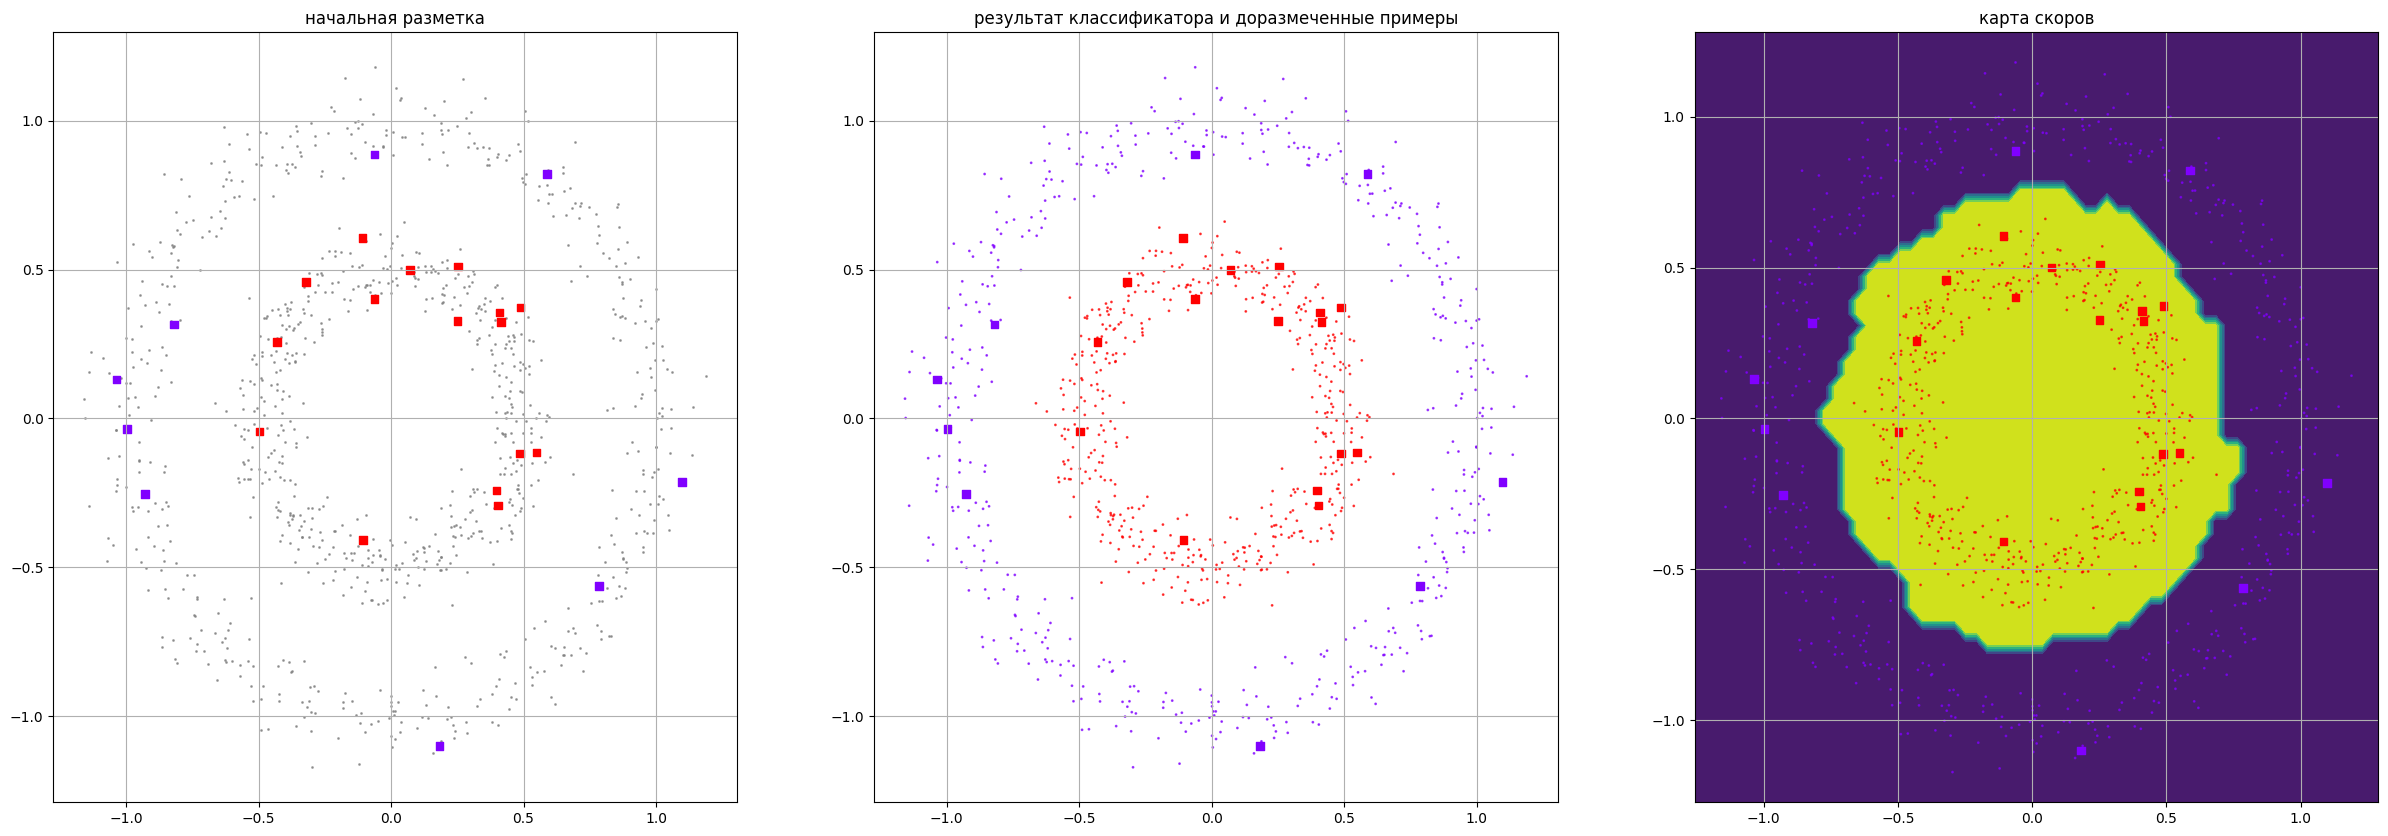

In [10]:
# from matplotlib.colors import ListedColormap

# from sklearn.preprocessing import MinMaxScaler
# # строим сетку 
# n = 64 # количество разбиений сетки
# xx,yy = np.meshgrid(
#     np.linspace( X[:,0].min()-0.1, X[:,0].max()+0.1, n), 
#     np.linspace( X[:,1].min()-0.1, X[:,1].max()+0.1, n)
# ) # узлы сетки
# xy = np.vstack([xx.ravel(),yy.ravel()]).T # разворачиваем сетку 


p = model.predict(X)

# from sklearn.metrics import classification_report
print(classification_report(y_true=target,y_pred=p))

fig,ax = plt.subplots(1,3,figsize=(30,10))

ax[0].scatter(X[indices_test,0],X[indices_test,1],c='grey',s=1,alpha=0.7)
ax[0].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[0].set_title('начальная разметка')
ax[0].grid()

ax[1].scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=1,alpha=0.7)
ax[1].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[1].set_title('результат классификатора и доразмеченные примеры')
ax[1].grid()

# вычисляем скор позитивных примеров для каждого узла сетки
score_xy = MinMaxScaler(feature_range=(0.,1.)).fit_transform( model.predict_proba(xy)[:,[1]] ).reshape(n,n) 
ax[2].contourf(xx, yy, score_xy )
ax[2].scatter(X[:,0],X[:,1],c=p,cmap='rainbow',s=1,alpha=0.7)
ax[2].scatter(X[indices_train,0],X[indices_train,1], c=target_train, cmap='rainbow',s=30, marker='s' )
ax[2].set_title('карта скоров')
ax[2].grid()

plt.show()